# B站全站排行榜数据分析

## 题目要求
（1）爬取B站「全站排行榜」前50名视频的基本信息（标题、UP主、播放量、点赞数、弹幕数、评论数、所属分区），并获取每个视频的前10条热门评论

（2）基于所爬取的排行榜数据，统计各分区视频的数量占比与平均互动率等信息，分析不同分区的内容表现差异，并进行可视化

（3）基于所爬取的评论数据，对每条评论进行多维度分析，包括情感倾向、评论意图分类、评论质量评估等

（4）扩展数据的爬取范围，并对所爬取数据进行其他维度的深入挖掘

---
## 第一题：数据爬取
爬取B站「全站排行榜」前50名视频的基本信息和热门评论

In [ ]:
# 第一题：数据爬取
import requests
import pandas as pd
import time
import random

# B站排行榜爬虫
class BilibiliCrawler:
    
    def __init__(self):
        # 请求头，模拟浏览器
        self.headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36',
            'Referer': 'https://www.bilibili.com',
        }
        self.session = requests.Session()
        self.session.headers.update(self.headers)
    
    def get_ranking_list(self):
        # 调用B站排行榜API
        url = 'https://api.bilibili.com/x/web-interface/ranking/v2'
        params = {'rid': 0, 'type': 'all'}
        
        response = self.session.get(url, params=params)
        data = response.json()
        
        if data['code'] == 0:
            return data['data']['list'][:50]  # 只要前50
        else:
            print(f"获取排行榜失败: {data['message']}")
            return []
    
    def get_video_info(self, bvid):
        # 根据bvid获取视频详情
        url = f'https://api.bilibili.com/x/web-interface/view?bvid={bvid}'
        response = self.session.get(url)
        data = response.json()
        
        if data['code'] == 0:
            return data['data']
        return None
    
    def get_video_comments(self, aid):
        # 获取视频的热门评论，取前10条
        url = 'https://api.bilibili.com/x/v2/reply/main'
        params = {
            'type': 1,
            'oid': aid,
            'mode': 3,  # 3表示按热度排序
            'ps': 10,
        }
        
        response = self.session.get(url, params=params)
        data = response.json()
        
        if data['code'] == 0 and data['data']['replies']:
            return data['data']['replies']
        return []
    
    def crawl(self):
        print("正在爬取B站排行榜...")
        
        ranking_data = self.get_ranking_list()
        print(f"拿到 {len(ranking_data)} 个视频")
        
        video_list = []
        comment_list = []
        
        for idx, video in enumerate(ranking_data, 1):
            print(f"正在处理第 {idx}/50 个: {video.get('title', '')[:20]}...")
            
            bvid = video.get('bvid', '')
            video_info = self.get_video_info(bvid)
            
            if video_info:
                stat = video_info.get('stat', {})
                # 保存视频基本信息
                video_list.append({
                    '排名': idx,
                    '标题': video_info.get('title', ''),
                    'UP主': video_info.get('owner', {}).get('name', ''),
                    '播放量': stat.get('view', 0),
                    '点赞数': stat.get('like', 0),
                    '弹幕数': stat.get('danmaku', 0),
                    '评论数': stat.get('reply', 0),
                    '分区': video_info.get('tname', ''),
                    '视频ID_bvid': bvid,
                    '视频ID_aid': video_info.get('aid', 0),
                })
                
                # 保存热门评论
                aid = video_info.get('aid', 0)
                comments = self.get_video_comments(aid)
                
                for cidx, comment in enumerate(comments, 1):
                    comment_list.append({
                        '视频排名': idx,
                        '视频标题': video_info.get('title', ''),
                        '热评排名': cidx,
                        '评论者': comment.get('member', {}).get('uname', ''),
                        '点赞数': comment.get('like', 0),
                        '评论内容': comment.get('content', {}).get('message', ''),
                    })
            
            # 随机延迟，别太快了
            time.sleep(random.uniform(0.5, 1.5))
        
        # 转成DataFrame，存csv
        video_df = pd.DataFrame(video_list)
        comment_df = pd.DataFrame(comment_list)
        
        video_df.to_csv('B站_Top50视频信息.csv', index=False, encoding='utf-8-sig')
        comment_df.to_csv('B站_Top50热门评论.csv', index=False, encoding='utf-8-sig')
        
        print(f"\n搞定！")
        print(f"视频 {len(video_df)} 条 -> B站_Top50视频信息.csv")
        print(f"评论 {len(comment_df)} 条 -> B站_Top50热门评论.csv")
        
        return video_df, comment_df

# 如果要爬新数据，把下面两行取消注释
# crawler = BilibiliCrawler()
# video_df, comment_df = crawler.crawl()

print('爬虫写好了，已有数据文件的话直接跳过这步就行')

---
## 第二题：分区统计分析与可视化
统计各分区视频的数量占比与平均互动率，分析不同分区的内容表现差异

In [ ]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['PingFang SC', 'Heiti TC', 'STHeiti', 'SimHei', 'Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus'] = False

# 加载数据
video_df = pd.read_csv('B站_Top50视频信息.csv')
comment_df = pd.read_csv('B站_Top50热门评论.csv')

# 计算互动率
video_df['互动率'] = video_df['点赞数'] / video_df['播放量']
video_df['总互动量'] = video_df['点赞数'] + video_df['弹幕数'] + video_df['评论数']

print(f'数据加载完成：{len(video_df)} 个视频，{len(comment_df)} 条评论')

In [ ]:
# 2.1 各分区视频数量统计与可视化
category_count = video_df['分区'].value_counts()

print('各分区视频数量:')
print(category_count)
print(f'\n共有 {len(category_count)} 个分区')

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 饼图
colors = plt.cm.Set3(np.linspace(0, 1, len(category_count)))
wedges, texts, autotexts = axes[0].pie(category_count.values, 
                                       labels=category_count.index,
                                       autopct='%1.1f%%',
                                       colors=colors,
                                       startangle=90)
axes[0].set_title('各分区视频数量占比', fontsize=14, fontweight='bold')

# 柱状图
x = range(len(category_count))
bars = axes[1].bar(x, category_count.values, color=colors)
axes[1].set_xticks(x)
axes[1].set_xticklabels(category_count.index, rotation=45, ha='right')
axes[1].set_ylabel('视频数量')
axes[1].set_title('各分区视频数量分布', fontsize=14, fontweight='bold')

for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [ ]:
# 2.2 各分区平均互动指标分析
category_stats = video_df.groupby('分区').agg({
    '播放量': 'mean',
    '点赞数': 'mean',
    '弹幕数': 'mean',
    '评论数': 'mean',
    '互动率': 'mean',
    '总互动量': 'mean'
}).round(2)

category_stats = category_stats.sort_values('播放量', ascending=False)

print('各分区平均互动指标:')
print(category_stats)

# 可视化 - 各分区平均播放量
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(category_stats.index[::-1], category_stats['播放量'][::-1], color='skyblue')
ax.set_xlabel('平均播放量')
ax.set_title('各分区平均播放量对比', fontsize=14, fontweight='bold')

for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, 
            f'{width:,.0f}', ha='left', va='center')

plt.tight_layout()
plt.show()

In [ ]:
# 2.3 播放量与互动率关系散点图
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(video_df['播放量'], 
                    video_df['互动率'],
                    s=video_df['总互动量']/10000,
                    c=video_df['排名'],
                    cmap='RdYlGn_r',
                    alpha=0.7, 
                    edgecolors='white')

plt.colorbar(scatter, label='排名')
ax.set_xlabel('播放量')
ax.set_ylabel('互动率')
ax.set_title('播放量与互动率关系（气泡大小表示总互动量）', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 第三题：评论多维度分析
对每条评论进行情感倾向、评论意图分类、评论质量评估等分析

In [ ]:
# 3.1 评论基础统计
print('评论基础统计:')
print(f'总评论数: {len(comment_df)}')
print(f'评论平均点赞数: {comment_df["点赞数"].mean():,.0f}')
print(f'评论最高点赞数: {comment_df["点赞数"].max():,}')

# 评论长度
comment_df['评论长度'] = comment_df['评论内容'].astype(str).apply(len)
print(f'\n评论平均长度: {comment_df["评论长度"].mean():.1f} 字符')

# 评论长度分布图
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(comment_df['评论长度'], bins=30, color='lightgreen', edgecolor='white', alpha=0.8)
ax.set_xlabel('评论长度（字符数）')
ax.set_ylabel('评论数量')
ax.set_title('评论长度分布', fontsize=14, fontweight='bold')
ax.axvline(comment_df['评论长度'].mean(), color='red', linestyle='--', 
           label=f'平均值: {comment_df["评论长度"].mean():.0f}')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 3.2 情感倾向分析
from snownlp import SnowNLP

def get_sentiment(text):
    """获取情感倾向（0-1之间，>0.5为正面）"""
    try:
        s = SnowNLP(str(text))
        return s.sentiments
    except:
        return 0.5

comment_df['情感分数'] = comment_df['评论内容'].apply(get_sentiment)
comment_df['情感标签'] = comment_df['情感分数'].apply(
    lambda x: '正面' if x > 0.7 else ('负面' if x < 0.3 else '中性')
)

sentiment_counts = comment_df['情感标签'].value_counts()
print('评论情感分布:')
print(sentiment_counts)
print(f'\n平均情感分数: {comment_df["情感分数"].mean():.3f}')

# 情感分布可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#95E1D3', '#F8B500', '#FF6B6B']

# 柱状图
bars = axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=colors)
axes[0].set_ylabel('评论数量')
axes[0].set_title('评论情感分布', fontsize=14, fontweight='bold')
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')

# 情感分数分布
axes[1].hist(comment_df['情感分数'], bins=30, color='lightblue', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('情感分数')
axes[1].set_ylabel('评论数量')
axes[1].set_title('情感分数分布', fontsize=14, fontweight='bold')
axes[1].axvline(0.5, color='red', linestyle='--', label='中性线')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# 3.3 评论意图分类
def classify_intent(text):
    """评论意图分类"""
    text = str(text)
    
    if any(word in text for word in ['喜欢', '爱', '好看', '牛', '厉害', '太棒', '感动', '泪目', '哈哈', '笑死', '可爱']):
        return '情感表达'
    elif any(word in text for word in ['?', '？', '怎么', '为什么', '什么', '哪里', '多少']):
        return '提问询问'
    elif any(word in text for word in ['我', '我的', '我们', '自己', '曾经', '以前']):
        return '分享经历'
    elif any(word in text for word in ['加油', '支持', '继续', '期待', '希望', '祝福', '平安']):
        return '鼓励支持'
    elif any(word in text for word in ['觉得', '认为', '感觉', '确实', '真的', '其实']):
        return '评价观点'
    else:
        return '其他'

comment_df['评论意图'] = comment_df['评论内容'].apply(classify_intent)

intent_counts = comment_df['评论意图'].value_counts()
print('评论意图分布:')
print(intent_counts)

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_intent = plt.cm.Set2(np.linspace(0, 1, len(intent_counts)))

# 饼图
wedges, texts, autotexts = axes[0].pie(intent_counts.values, 
                                       labels=intent_counts.index,
                                       autopct='%1.1f%%',
                                       colors=colors_intent,
                                       startangle=90)
axes[0].set_title('评论意图分布', fontsize=14, fontweight='bold')

# 各意图平均点赞数
intent_likes = comment_df.groupby('评论意图')['点赞数'].mean().sort_values(ascending=True)
bars = axes[1].barh(intent_likes.index, intent_likes.values, color=colors_intent)
axes[1].set_xlabel('平均点赞数')
axes[1].set_title('各意图类别平均点赞数', fontsize=14, fontweight='bold')

for bar in bars:
    width = bar.get_width()
    axes[1].text(width, bar.get_y() + bar.get_height()/2, 
                f'{width:,.0f}', ha='left', va='center')

plt.tight_layout()
plt.show()

In [ ]:
# 3.4 评论质量评估
def assess_quality(row):
    """评论质量评估（1-5分）"""
    score = 0
    text = str(row['评论内容'])
    
    # 长度得分（0-1分）
    if len(text) > 50:
        score += 1
    elif len(text) > 20:
        score += 0.5
    
    # 点赞数得分（0-2分）
    likes = row['点赞数']
    if likes > 10000:
        score += 2
    elif likes > 5000:
        score += 1.5
    elif likes > 1000:
        score += 1
    elif likes > 100:
        score += 0.5
    
    # 内容质量（0-2分）
    if any(word in text for word in ['因为', '所以', '但是', '虽然', '如果']):
        score += 1
    if any(word in text for word in ['喜欢', '感动', '厉害', '好看', '牛']):
        score += 0.5
    if '@' in text or '#' in text:
        score += 0.5
    
    return min(score, 5)

comment_df['质量评分'] = comment_df.apply(assess_quality, axis=1)
comment_df['质量等级'] = pd.cut(comment_df['质量评分'], 
                              bins=[0, 1, 2, 3, 4, 5],
                              labels=['很差', '较差', '一般', '较好', '优秀'])

quality_counts = comment_df['质量等级'].value_counts()
print('评论质量分布:')
print(quality_counts)
print(f'\n平均质量评分: {comment_df["质量评分"].mean():.2f}')

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_quality = ['#FF6B6B', '#FFA07A', '#FFD700', '#98FB98', '#4ECDC4']

# 饼图
wedges, texts, autotexts = axes[0].pie(quality_counts.values, 
                                       labels=quality_counts.index,
                                       autopct='%1.1f%%',
                                       colors=colors_quality,
                                       startangle=90)
axes[0].set_title('评论质量分布', fontsize=14, fontweight='bold')

# 质量评分分布
axes[1].hist(comment_df['质量评分'], bins=10, color='lightcoral', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('质量评分')
axes[1].set_ylabel('评论数量')
axes[1].set_title('质量评分分布', fontsize=14, fontweight='bold')
axes[1].axvline(comment_df['质量评分'].mean(), color='red', linestyle='--', 
                label=f'平均值: {comment_df["质量评分"].mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

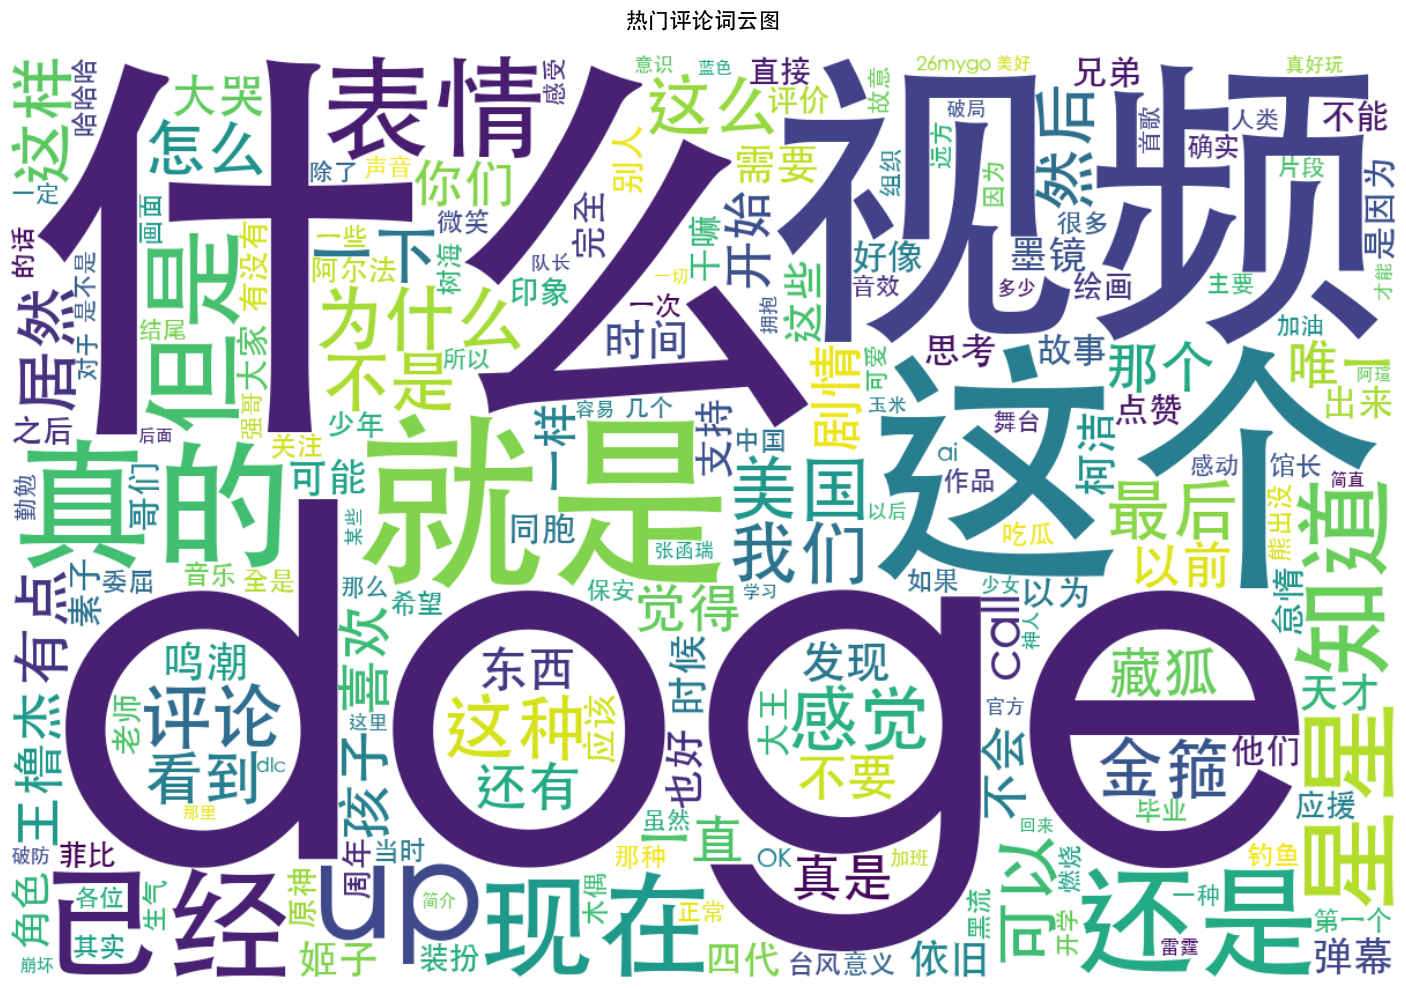


评论高频词TOP20:
doge: 46
什么: 33
视频: 31
这个: 30
就是: 22
真的: 22
up: 19
已经: 19
还是: 19
现在: 19
表情: 19
星星: 18
但是: 17
知道: 16
为什么: 15
感觉: 15
评论: 15
这种: 15
美国: 15
我们: 14


In [22]:
# 3.5 评论词云图
from collections import Counter
import jieba
from wordcloud import WordCloud

all_comments = ' '.join(comment_df['评论内容'].astype(str).tolist())
words = jieba.cut(all_comments)
word_list = [word for word in words if len(word) > 1]
word_freq = Counter(word_list)

stopwords = {'的', '了', '是', '在', '我', '有', '和', '就', '不', '人', '都', '一', '一个', '上', '也', '很', '到', '说', '要', '去', '你', '会', '着', '没有', '看', '好', '自己', '这'}
word_freq = {k: v for k, v in word_freq.items() if k not in stopwords}

# 词云图
wc = WordCloud(
    font_path='/System/Library/Fonts/STHeiti Medium.ttc',
    width=1200,
    height=800,
    background_color='white',
    max_words=200,
    colormap='viridis',
    random_state=42
)
wc.generate_from_frequencies(word_freq)

fig, ax = plt.subplots(figsize=(15, 10))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('热门评论词云图', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# 高频词TOP20
top_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)[:20]
print('\n评论高频词TOP20:')
for word, freq in top_words:
    print(f'{word}: {freq}')

---
## 第四题：扩展数据挖掘
对数据进行其他维度的深入挖掘分析

In [ ]:
# 4.1 UP主影响力分析
up_stats = video_df.groupby('UP主').agg({
    '排名': 'count',
    '播放量': 'sum',
    '点赞数': 'sum',
    '总互动量': 'sum'
}).rename(columns={'排名': '视频数量'})

# 多次上榜的UP主
multi_up = up_stats[up_stats['视频数量'] > 1].sort_values('视频数量', ascending=False)

print('多次上榜的UP主:')
print(multi_up)

# TOP10 UP主
top_up = up_stats.nlargest(10, '总互动量')

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# UP主视频数量分布
up_count_dist = up_stats['视频数量'].value_counts().sort_index()
bars1 = axes[0].bar(up_count_dist.index.astype(str), up_count_dist.values, color='lightblue')
axes[0].set_xlabel('视频数量')
axes[0].set_ylabel('UP主数量')
axes[0].set_title('UP主视频数量分布', fontsize=14, fontweight='bold')
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')

# TOP10 UP主总互动量
bars2 = axes[1].barh(top_up.index[::-1], top_up['总互动量'][::-1], color='coral')
axes[1].set_xlabel('总互动量')
axes[1].set_title('TOP10 UP主总互动量', fontsize=14, fontweight='bold')
for bar in bars2:
    width = bar.get_width()
    axes[1].text(width, bar.get_y() + bar.get_height()/2, 
                f'{width:,.0f}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# 4.2 视频标题关键词分析
import jieba

all_title_words = []
for title in video_df['标题']:
    words = jieba.cut(str(title))
    all_title_words.extend([word for word in words if len(word) > 1])

title_word_freq = Counter(all_title_words)
title_stopwords = {'的', '了', '是', '在', '我', '有', '和', '就', '不', '人', '都', '一', '上', '也', '很', '到', '说', '要', '去', '你', '会', '着', '看', '好', '这', '什么', '怎么', '！', '？', '，', '。'}
title_word_freq = {k: v for k, v in title_word_freq.items() if k not in title_stopwords}

top_title_words = sorted(title_word_freq.items(), key=lambda x: x[1], reverse=True)[:20]

print('视频标题高频词TOP20:')
for word, freq in top_title_words:
    print(f'{word}: {freq}')

# 可视化
fig, ax = plt.subplots(figsize=(12, 8))
words_list, freqs = zip(*top_title_words)
bars = ax.barh(list(words_list)[::-1], list(freqs)[::-1], color='orange')
ax.set_xlabel('出现次数')
ax.set_title('标题高频词TOP20', fontsize=14, fontweight='bold')

for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, 
            f'{int(width)}', ha='left', va='center')

plt.tight_layout()
plt.show()

In [ ]:
# 4.3 互动指标相关性分析
interaction_cols = ['播放量', '点赞数', '弹幕数', '评论数', '互动率', '总互动量']
corr_matrix = video_df[interaction_cols].corr()

print('互动指标相关性矩阵:')
print(corr_matrix.round(3))

# 热力图
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)

# 设置刻度
ax.set_xticks(range(len(interaction_cols)))
ax.set_yticks(range(len(interaction_cols)))
ax.set_xticklabels(interaction_cols, rotation=45, ha='right')
ax.set_yticklabels(interaction_cols)

# 添加数值
for i in range(len(interaction_cols)):
    for j in range(len(interaction_cols)):
        text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                       ha='center', va='center', color='black', fontsize=10)

plt.colorbar(im)
ax.set_title('互动指标相关性热力图', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [ ]:
# 4.4 综合评分模型
def calculate_comprehensive_score(row):
    """计算视频综合评分"""
    play_score = (row['播放量'] / video_df['播放量'].max()) * 30
    interaction_score = (row['互动率'] / video_df['互动率'].max()) * 30
    total_score = (row['总互动量'] / video_df['总互动量'].max()) * 20
    rank_score = ((51 - row['排名']) / 50) * 20
    return play_score + interaction_score + total_score + rank_score

video_df['综合评分'] = video_df.apply(calculate_comprehensive_score, axis=1)

# 综合评分TOP10
top_comprehensive = video_df.nlargest(10, '综合评分')

print('综合评分TOP10视频:')
for idx, row in top_comprehensive.iterrows():
    print(f"排名{row['排名']}: {row['标题'][:25]}... | 综合评分: {row['综合评分']:.2f}")

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 综合评分分布
axes[0].hist(video_df['综合评分'], bins=20, color='lightgreen', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('综合评分')
axes[0].set_ylabel('视频数量')
axes[0].set_title('综合评分分布', fontsize=14, fontweight='bold')
axes[0].axvline(video_df['综合评分'].mean(), color='red', linestyle='--', 
                label=f'平均值: {video_df["综合评分"].mean():.2f}')
axes[0].legend()

# 排名与综合评分关系
scatter = axes[1].scatter(video_df['排名'], video_df['综合评分'], 
                         c=video_df['播放量'], s=100, cmap='viridis', alpha=0.7)
axes[1].set_xlabel('排名')
axes[1].set_ylabel('综合评分')
axes[1].set_title('排名与综合评分关系', fontsize=14, fontweight='bold')
plt.colorbar(scatter, ax=axes[1], label='播放量')

plt.tight_layout()
plt.show()

---
## 完整数据分析代码汇总
将所有数据分析代码整合在一起

第一题：数据加载
视频数据: 50 条
评论数据: 470 条

第二题：分区统计分析

各分区视频数量（共25个分区）:
分区
日常               10
搞笑                5
手机游戏              3
娱乐粉丝创作            3
翻唱                2
音乐综合              2
单机游戏              2
MMD·3D            2
小剧场               2
影视剪辑              2
MAD·AMV           2
MV                2
运动综合              1
特摄                1
科学科普              1
汽车生活              1
综合                1
鬼畜剧场              1
喵星人               1
演奏                1
出行                1
数码                1
明星综合              1
VOCALOID·UTAU     1
手工                1
Name: count, dtype: int64

各分区平均互动指标:
                       播放量        点赞数   互动率        总互动量
分区                                                     
汽车生活           13436842.00  415572.00  0.03   431452.00
鬼畜剧场            6328419.00  535452.00  0.08   552526.00
演奏              5938893.00  480916.00  0.08   487154.00
影视剪辑            4877171.50  218699.50  0.04   222436.00
数码              4657659.00  179785.00  0.04   200196.00
日常   

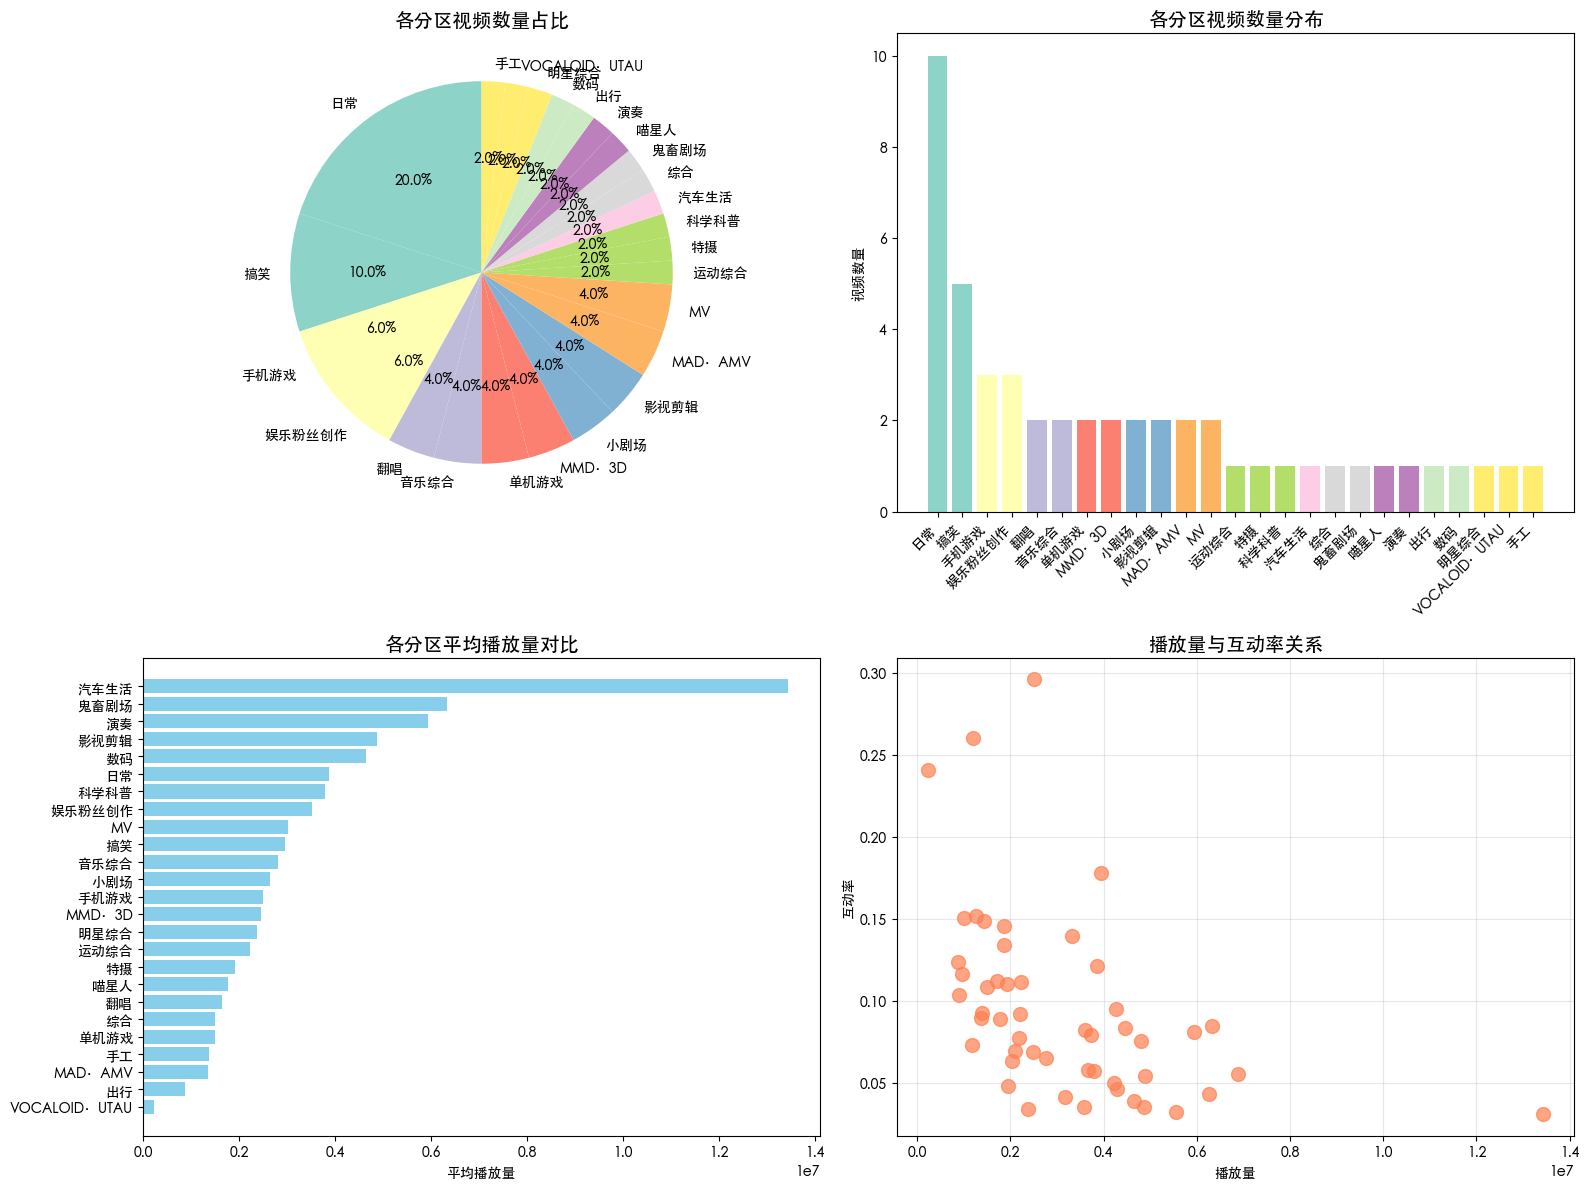


第三题：评论多维度分析

情感分布:
情感标签
正面    259
中性    120
负面     91
Name: count, dtype: int64
平均情感分数: 0.665

意图分布:
评论意图
其他      281
分享经历     89
提问询问     51
情感表达     42
鼓励支持      7
Name: count, dtype: int64

平均质量评分: 1.05/5


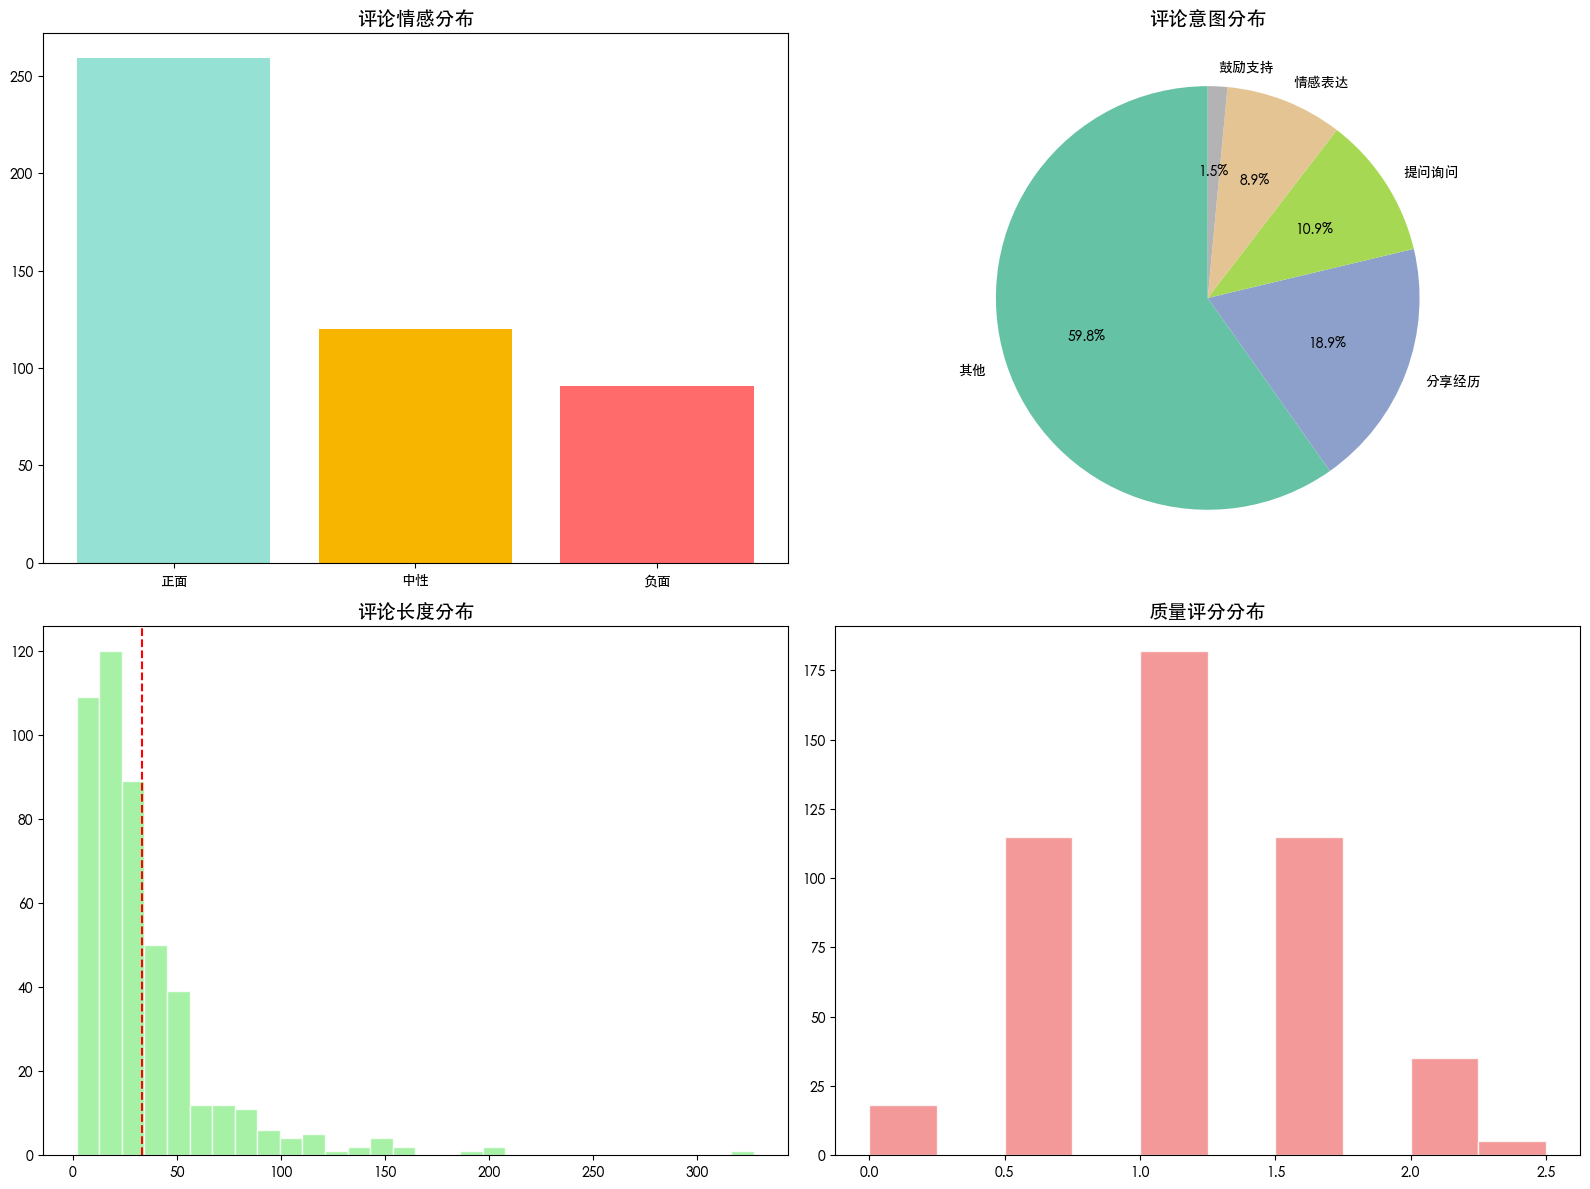

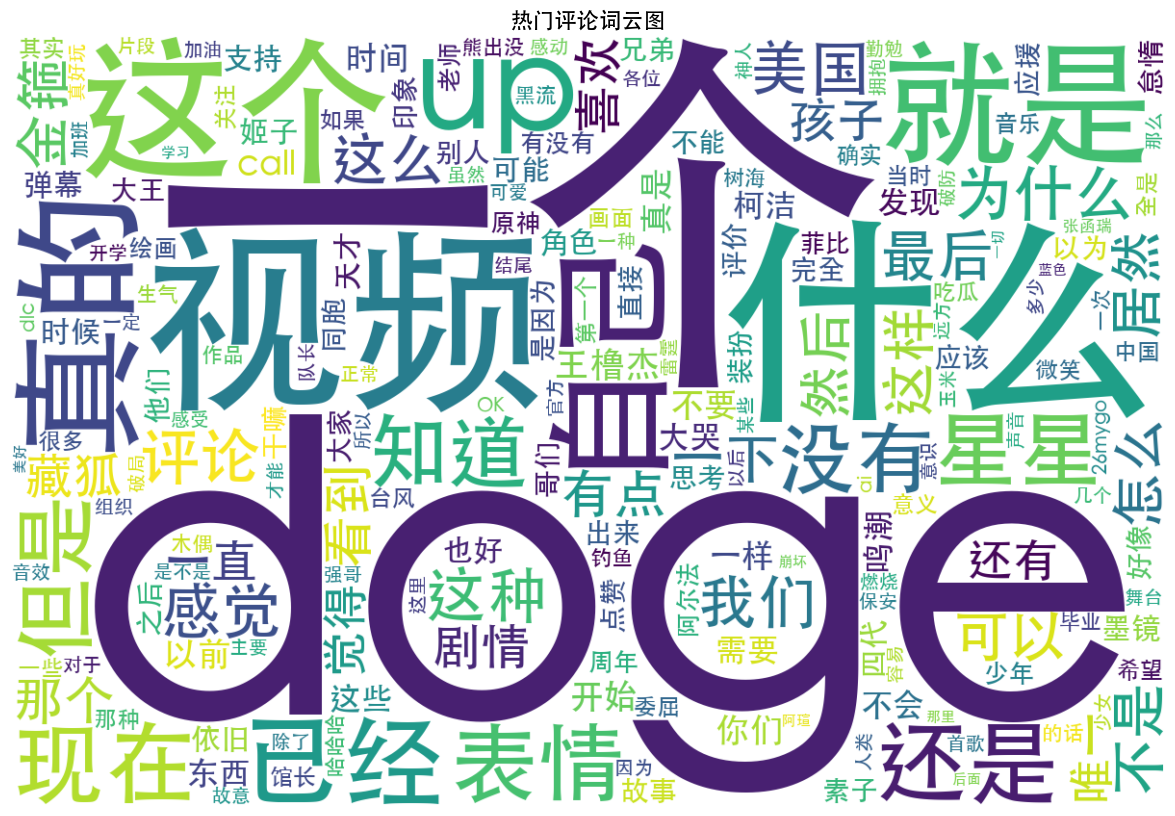


第四题：扩展数据挖掘

多次上榜UP主: 0 位
Empty DataFrame
Columns: [视频数量, 播放量, 总互动量]
Index: []


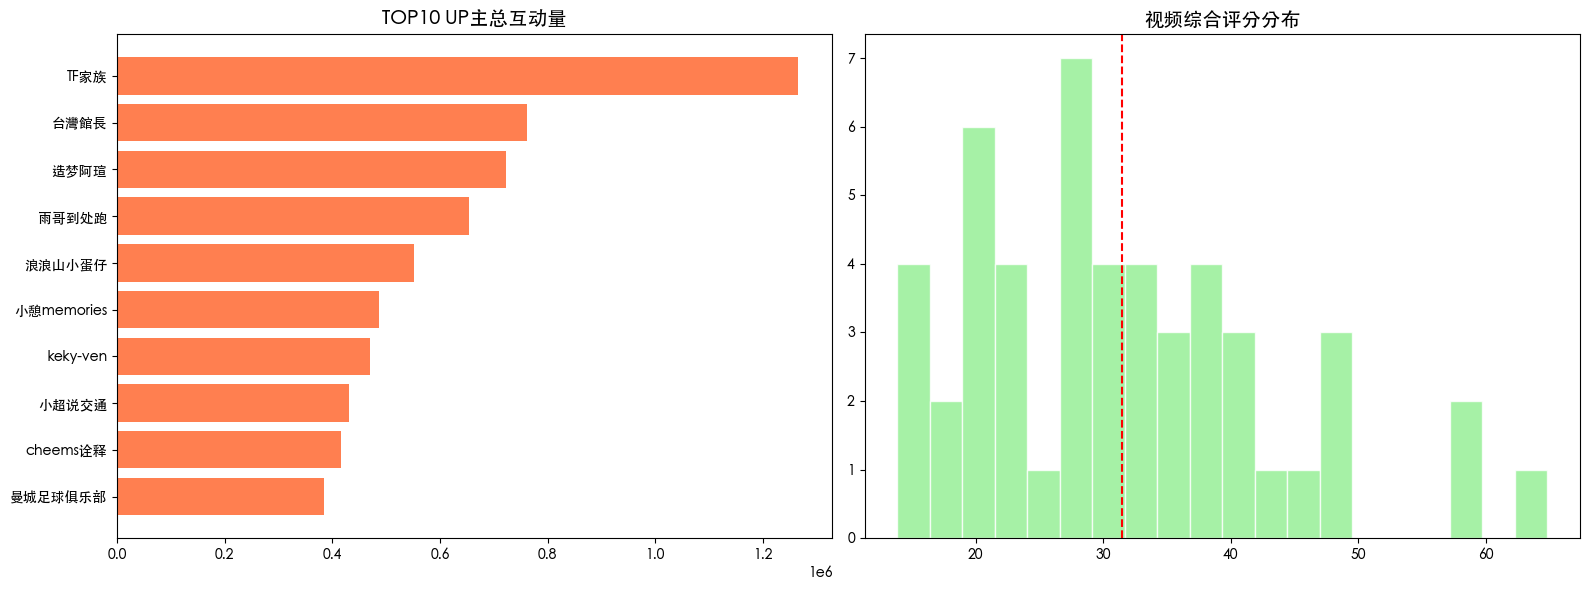


分析报告

数据概况:
- 分析视频: 50 个
- 分析评论: 470 条
- 涵盖分区: 25 个

核心发现:
- 热门分区TOP3: ['日常', '搞笑', '手机游戏']
- 平均互动率: 9.55%
- 正面评论占比: 55.1%
- 平均评论质量: 1.05/5

分析完成！


In [23]:
# ============================================================
# B站全站排行榜数据分析 - 完整代码汇总
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from collections import Counter
from snownlp import SnowNLP
import jieba
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
matplotlib.rcParams['font.sans-serif'] = ['PingFang SC', 'Heiti TC', 'STHeiti', 'SimHei', 'Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus'] = False

# ============ 第一题：数据加载 ============
print('='*60)
print('第一题：数据加载')
print('='*60)

video_df = pd.read_csv('B站_Top50视频信息.csv')
comment_df = pd.read_csv('B站_Top50热门评论.csv')

# 计算衍生指标
video_df['互动率'] = video_df['点赞数'] / video_df['播放量']
video_df['总互动量'] = video_df['点赞数'] + video_df['弹幕数'] + video_df['评论数']
comment_df['评论长度'] = comment_df['评论内容'].astype(str).apply(len)

print(f'视频数据: {len(video_df)} 条')
print(f'评论数据: {len(comment_df)} 条')

# ============ 第二题：分区统计分析 ============
print('\n' + '='*60)
print('第二题：分区统计分析')
print('='*60)

# 2.1 各分区视频数量
category_count = video_df['分区'].value_counts()
print(f'\n各分区视频数量（共{len(category_count)}个分区）:')
print(category_count)

# 2.2 各分区平均互动指标
category_stats = video_df.groupby('分区').agg({
    '播放量': 'mean',
    '点赞数': 'mean',
    '互动率': 'mean',
    '总互动量': 'mean'
}).round(2).sort_values('播放量', ascending=False)

print('\n各分区平均互动指标:')
print(category_stats)

# 2.3 可视化
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 饼图
colors = plt.cm.Set3(np.linspace(0, 1, len(category_count)))
axes[0,0].pie(category_count.values, labels=category_count.index, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0,0].set_title('各分区视频数量占比', fontsize=14, fontweight='bold')

# 柱状图 - 分区数量
x = range(len(category_count))
bars = axes[0,1].bar(x, category_count.values, color=colors)
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(category_count.index, rotation=45, ha='right')
axes[0,1].set_ylabel('视频数量')
axes[0,1].set_title('各分区视频数量分布', fontsize=14, fontweight='bold')

# 柱状图 - 平均播放量
bars = axes[1,0].barh(category_stats.index[::-1], category_stats['播放量'][::-1], color='skyblue')
axes[1,0].set_xlabel('平均播放量')
axes[1,0].set_title('各分区平均播放量对比', fontsize=14, fontweight='bold')

# 散点图
scatter = axes[1,1].scatter(video_df['播放量'], video_df['互动率'], s=100, alpha=0.7, c='coral')
axes[1,1].set_xlabel('播放量')
axes[1,1].set_ylabel('互动率')
axes[1,1].set_title('播放量与互动率关系', fontsize=14, fontweight='bold')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============ 第三题：评论多维度分析 ============
print('\n' + '='*60)
print('第三题：评论多维度分析')
print('='*60)

# 3.1 情感分析
def get_sentiment(text):
    try:
        s = SnowNLP(str(text))
        return s.sentiments
    except:
        return 0.5

comment_df['情感分数'] = comment_df['评论内容'].apply(get_sentiment)
comment_df['情感标签'] = comment_df['情感分数'].apply(lambda x: '正面' if x > 0.7 else ('负面' if x < 0.3 else '中性'))

sentiment_counts = comment_df['情感标签'].value_counts()
print(f'\n情感分布:')
print(sentiment_counts)
print(f'平均情感分数: {comment_df["情感分数"].mean():.3f}')

# 3.2 意图分类
def classify_intent(text):
    text = str(text)
    if any(word in text for word in ['喜欢', '爱', '好看', '牛', '厉害', '感动', '哈哈']):
        return '情感表达'
    elif any(word in text for word in ['?', '？', '怎么', '为什么']):
        return '提问询问'
    elif any(word in text for word in ['我', '我的', '我们']):
        return '分享经历'
    elif any(word in text for word in ['加油', '支持', '期待', '希望']):
        return '鼓励支持'
    else:
        return '其他'

comment_df['评论意图'] = comment_df['评论内容'].apply(classify_intent)
intent_counts = comment_df['评论意图'].value_counts()
print(f'\n意图分布:')
print(intent_counts)

# 3.3 质量评估
def assess_quality(row):
    score = 0
    text = str(row['评论内容'])
    if len(text) > 50: score += 1
    elif len(text) > 20: score += 0.5
    if row['点赞数'] > 10000: score += 2
    elif row['点赞数'] > 1000: score += 1
    elif row['点赞数'] > 100: score += 0.5
    return min(score, 5)

comment_df['质量评分'] = comment_df.apply(assess_quality, axis=1)
print(f'\n平均质量评分: {comment_df["质量评分"].mean():.2f}/5')

# 3.4 可视化
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 情感分布
colors_sentiment = ['#95E1D3', '#F8B500', '#FF6B6B']
axes[0,0].bar(sentiment_counts.index, sentiment_counts.values, color=colors_sentiment)
axes[0,0].set_title('评论情感分布', fontsize=14, fontweight='bold')

# 意图分布
colors_intent = plt.cm.Set2(np.linspace(0, 1, len(intent_counts)))
axes[0,1].pie(intent_counts.values, labels=intent_counts.index, autopct='%1.1f%%', colors=colors_intent, startangle=90)
axes[0,1].set_title('评论意图分布', fontsize=14, fontweight='bold')

# 评论长度分布
axes[1,0].hist(comment_df['评论长度'], bins=30, color='lightgreen', edgecolor='white', alpha=0.8)
axes[1,0].set_title('评论长度分布', fontsize=14, fontweight='bold')
axes[1,0].axvline(comment_df['评论长度'].mean(), color='red', linestyle='--')

# 质量评分分布
axes[1,1].hist(comment_df['质量评分'], bins=10, color='lightcoral', edgecolor='white', alpha=0.8)
axes[1,1].set_title('质量评分分布', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# 3.5 词云图
all_comments = ' '.join(comment_df['评论内容'].astype(str).tolist())
words = jieba.cut(all_comments)
word_list = [word for word in words if len(word) > 1]
word_freq = Counter(word_list)
stopwords = {'的', '了', '是', '在', '我', '有', '和', '就', '不', '人', '都', '一', '上', '也', '很', '到', '说', '要', '去', '你', '会', '着', '看', '好', '这'}
word_freq = {k: v for k, v in word_freq.items() if k not in stopwords}

wc = WordCloud(font_path='/System/Library/Fonts/STHeiti Medium.ttc', width=1200, height=800, background_color='white', max_words=200, colormap='viridis', random_state=42)
wc.generate_from_frequencies(word_freq)

fig, ax = plt.subplots(figsize=(15, 10))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('热门评论词云图', fontsize=16, fontweight='bold')
plt.show()

# ============ 第四题：扩展分析 ============
print('\n' + '='*60)
print('第四题：扩展数据挖掘')
print('='*60)

# 4.1 UP主影响力
up_stats = video_df.groupby('UP主').agg({'排名': 'count', '播放量': 'sum', '总互动量': 'sum'}).rename(columns={'排名': '视频数量'})
multi_up = up_stats[up_stats['视频数量'] > 1]
print(f'\n多次上榜UP主: {len(multi_up)} 位')
print(multi_up)

# 4.2 综合评分
def calculate_score(row):
    play = (row['播放量'] / video_df['播放量'].max()) * 30
    inter = (row['互动率'] / video_df['互动率'].max()) * 30
    total = (row['总互动量'] / video_df['总互动量'].max()) * 20
    rank = ((51 - row['排名']) / 50) * 20
    return play + inter + total + rank

video_df['综合评分'] = video_df.apply(calculate_score, axis=1)

# 4.3 可视化
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# TOP10 UP主
top_up = up_stats.nlargest(10, '总互动量')
axes[0].barh(top_up.index[::-1], top_up['总互动量'][::-1], color='coral')
axes[0].set_title('TOP10 UP主总互动量', fontsize=14, fontweight='bold')

# 综合评分分布
axes[1].hist(video_df['综合评分'], bins=20, color='lightgreen', edgecolor='white', alpha=0.8)
axes[1].set_title('视频综合评分分布', fontsize=14, fontweight='bold')
axes[1].axvline(video_df['综合评分'].mean(), color='red', linestyle='--')

plt.tight_layout()
plt.show()

# ============ 分析报告 ============
print('\n' + '='*60)
print('分析报告')
print('='*60)
print(f'\n数据概况:')
print(f'- 分析视频: {len(video_df)} 个')
print(f'- 分析评论: {len(comment_df)} 条')
print(f'- 涵盖分区: {len(category_count)} 个')
print(f'\n核心发现:')
print(f'- 热门分区TOP3: {list(category_count.index[:3])}')
print(f'- 平均互动率: {video_df["互动率"].mean():.2%}')
print(f'- 正面评论占比: {len(comment_df[comment_df["情感标签"]=="正面"])/len(comment_df)*100:.1f}%')
print(f'- 平均评论质量: {comment_df["质量评分"].mean():.2f}/5')
print('\n' + '='*60)
print('分析完成！')
print('='*60)